# NDVI Buffer Mean — Sentinel-2 (GEE)

**Mục tiêu:** Tính NDVI trung bình không gian trong buffer quanh 6 trạm Hà Nội  
**Khác với `ndvi_mean` hiện có:** `ndvi_mean` trong daily_merged là giá trị theo **ngày** tại pixel trạm.  
NDVI buffer là đặc trưng **tĩnh** — trung bình nhiều năm trong bán kính 500m/1km/2km,  
phản ánh độ phủ xanh tổng thể của môi trường xung quanh trạm.

**Product:** `COPERNICUS/S2_SR_HARMONIZED` (Sentinel-2 Surface Reflectance)  
**NDVI:** `(B8 - B4) / (B8 + B4)`  
**Period:** 2024-01-01 → 2025-12-31 (2 năm, lọc mây < 20%)  
**Buffer sizes:** 500m, 1km, 2km  

**Output:** `data/processed/station_spatial_features.csv`  
**Features tạo ra:**
| Feature | Mô tả |
|---------|-------|
| `ndvi_buffer_500m` | NDVI trung bình trong buffer 500m (2 năm) |
| `ndvi_buffer_1km` | NDVI trung bình trong buffer 1km |
| `ndvi_buffer_2km` | NDVI trung bình trong buffer 2km |
| `ndvi_buffer_500m_std` | Độ lệch chuẩn NDVI 500m (độ đồng nhất thảm thực vật) |

## Cell 1 — Cài đặt & Initialize GEE

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'earthengine-api'])

import ee

GEE_PROJECT = 'silken-gadget-419107'

try:
    ee.Initialize(project=GEE_PROJECT)
    print('GEE initialized OK.')
except ee.EEException:
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)
    print('GEE initialized OK (after auth).')

# Kiểm tra collection
n = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
      .filterDate('2024-01-01', '2024-01-07') \
      .filterBounds(ee.Geometry.Point([105.83, 21.02])) \
      .size().getInfo()
print(f'S2 images in first week Jan 2024 over Hanoi: {n}  -> OK')

GEE initialized OK.


S2 images in first week Jan 2024 over Hanoi: 1  -> OK


## Cell 2 — Cấu hình

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT     = Path('D:/Bussiness_plan/Multimodal_PM25')
PROC_DIR = ROOT / 'data/processed'
OUT_CSV  = PROC_DIR / 'station_spatial_features.csv'
MERGED   = PROC_DIR / 'daily_merged.csv'

STATIONS = {
    2161292: {'lat': 21.0152, 'lon': 105.7999, 'name': 'Phố Lưu Quang Vũ'},
    2161306: {'lat': 21.0500, 'lon': 105.7400, 'name': 'Minh Khai - Bắc Từ Liêm'},
    4946811: {'lat': 21.0491, 'lon': 105.8831, 'name': 'Trạm 4946811'},
    4946812: {'lat': 21.0031, 'lon': 105.7947, 'name': 'Trạm 4946812'},
    4946813: {'lat': 21.0052, 'lon': 105.8418, 'name': 'Trạm 4946813'},
    6123215: {'lat': 20.9933, 'lon': 105.9441, 'name': 'Trạm 6123215'},
}

DATE_START   = '2024-01-01'
DATE_END     = '2025-12-31'
CLOUD_MAX    = 20           # % cloud cover tối đa
BUFFER_SIZES = [500, 1000, 2000]

print(f'Stations  : {len(STATIONS)}')
print(f'Period    : {DATE_START} to {DATE_END}')
print(f'Cloud max : {CLOUD_MAX}%')
print(f'Buffers   : {BUFFER_SIZES} m')

Stations  : 6
Period    : 2024-01-01 to 2025-12-31
Cloud max : 20%
Buffers   : [500, 1000, 2000] m


## Cell 3 — Build Sentinel-2 NDVI composite

Tạo một ảnh tổng hợp (median composite) NDVI từ toàn bộ ảnh S2 trong 2 năm,  
sau đó extract giá trị trong buffer quanh từng trạm.

In [3]:
def mask_s2_clouds(image):
    """Mask mây bằng SCL band (Scene Classification Layer)."""
    scl = image.select('SCL')
    # SCL classes: 4=Vegetation, 5=Bare soil, 6=Water, 11=Snow
    # Loại bỏ: 3=Cloud shadow, 8=Cloud medium, 9=Cloud high, 10=Thin cirrus
    clear_mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return image.updateMask(clear_mask)


def add_ndvi(image):
    """Tính NDVI = (B8 - B4) / (B8 + B4)."""
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)


# Build composite
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterDate(DATE_START, DATE_END)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', CLOUD_MAX))
      .filterBounds(ee.Geometry.Rectangle([105.6, 20.8, 106.1, 21.2]))  # Hanoi bbox
      .map(mask_s2_clouds)
      .map(add_ndvi))

n_images = s2.size().getInfo()
print(f'S2 images after cloud filter: {n_images}')

# Median composite — dùng median để robust với outlier còn sót
ndvi_composite = s2.select('NDVI').median()

# Kiểm tra nhanh tại tâm Hà Nội
test_val = ndvi_composite.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=ee.Geometry.Point([105.83, 21.02]),
    scale=10
).getInfo()
print(f'NDVI test at Hoan Kiem: {test_val}  (urban area, expected ~0.1–0.2)')

S2 images after cloud filter: 35


NDVI test at Hoan Kiem: {'NDVI': 0.19266682863235474}  (urban area, expected ~0.1–0.2)


## Cell 4 — Extract NDVI buffer cho từng trạm × buffer size

> 6 trạm × 3 buffer sizes × 2 reducers (mean + std) = 36 GEE calls → **~2–3 phút**

In [4]:
import time

def extract_ndvi_buffer(lat, lon, buffer_m):
    """Trả về mean và std NDVI trong buffer quanh (lat, lon)."""
    region = ee.Geometry.Point([lon, lat]).buffer(buffer_m)

    stats = ndvi_composite.reduceRegion(
        reducer=ee.Reducer.mean().combine(
            ee.Reducer.stdDev(), sharedInputs=True
        ).combine(
            ee.Reducer.percentile([10, 90]), sharedInputs=True
        ),
        geometry=region,
        scale=10,          # Sentinel-2 native 10m
        maxPixels=1e7
    ).getInfo()

    return {
        'mean': stats.get('NDVI_mean'),
        'std':  stats.get('NDVI_stdDev'),
        'p10':  stats.get('NDVI_p10'),
        'p90':  stats.get('NDVI_p90'),
    }


rows = []

for sid, sinfo in STATIONS.items():
    lat, lon = sinfo['lat'], sinfo['lon']
    print(f'\nStation {sid} ({sinfo["name"]})...')

    row = {'location_id': sid}

    for buf_m in BUFFER_SIZES:
        label = f'{buf_m}m' if buf_m < 1000 else f'{buf_m//1000}km'
        for attempt in range(3):
            try:
                r = extract_ndvi_buffer(lat, lon, buf_m)
                row[f'ndvi_buffer_{label}']     = round(r['mean'], 4) if r['mean'] is not None else None
                row[f'ndvi_buffer_{label}_std'] = round(r['std'],  4) if r['std']  is not None else None
                row[f'ndvi_buffer_{label}_p10'] = round(r['p10'],  4) if r['p10']  is not None else None
                row[f'ndvi_buffer_{label}_p90'] = round(r['p90'],  4) if r['p90']  is not None else None
                print(f'  {label:5s}: mean={row[f"ndvi_buffer_{label}"]:.4f}  '
                      f'std={row[f"ndvi_buffer_{label}_std"]:.4f}  '
                      f'p10={row[f"ndvi_buffer_{label}_p10"]:.4f}  '
                      f'p90={row[f"ndvi_buffer_{label}_p90"]:.4f}')
                break
            except Exception as e:
                if attempt == 2:
                    print(f'  {label}: FAILED — {e}')
                    for sfx in ['', '_std', '_p10', '_p90']:
                        row[f'ndvi_buffer_{label}{sfx}'] = None
                else:
                    time.sleep(5)

    rows.append(row)

df_ndvi = pd.DataFrame(rows)
print(f'\nShape: {df_ndvi.shape}')
print(df_ndvi[['location_id'] + [c for c in df_ndvi.columns if 'mean' in c]].to_string(index=False))


Station 2161292 (Phố Lưu Quang Vũ)...


  500m : mean=0.2538  std=0.1508  p10=0.1035  p90=0.4864


  1km  : mean=0.2506  std=0.1649  p10=0.0899  p90=0.5041


  2km  : mean=0.2443  std=0.1788  p10=0.0665  p90=0.5195

Station 2161306 (Minh Khai - Bắc Từ Liêm)...


  500m : mean=0.2705  std=0.1865  p10=0.0920  p90=0.5637


...

  1km  : mean=0.2354  std=0.1844  p10=0.0586  p90=0.5275


  2km  : mean=0.2254  std=0.1703  p10=0.0822  p90=0.4883

Station 6123215 (Trạm 6123215)...


  500m : mean=0.2647  std=0.1720  p10=0.0823  p90=0.5119


  1km  : mean=0.2567  std=0.2323  p10=-0.0438  p90=0.5742


  2km  : mean=0.3782  std=0.2500  p10=0.0899  p90=0.7226

Shape: (6, 13)
 location_id
     2161292
     2161306
     4946811
     4946812
     4946813
     6123215


## Cell 5 — Seasonal NDVI (winter vs summer per station)

In [5]:
# Tách theo mùa: winter (Nov-Mar) vs summer (May-Sep)
# Mùa đông Hà Nội: ô nhiễm cao, NDVI thấp (lá rụng / sương mù)
# Mùa hè: NDVI cao, ô nhiễm thấp hơn

def seasonal_ndvi(lat, lon, buffer_m, months):
    region = ee.Geometry.Point([lon, lat]).buffer(buffer_m)
    month_filter = ee.Filter.calendarRange(months[0], months[-1], 'month')
    comp = (s2.filter(month_filter)
             .select('NDVI')
             .median())
    val = comp.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=10, maxPixels=1e7
    ).getInfo()
    return val.get('NDVI')

WINTER_MONTHS = [11, 12, 1, 2, 3]   # Nov-Mar (ô nhiễm cao)
SUMMER_MONTHS = [5, 6, 7, 8, 9]     # May-Sep

print('Computing seasonal NDVI at buffer 1km...')
for i, row in df_ndvi.iterrows():
    sid  = row['location_id']
    lat  = STATIONS[sid]['lat']
    lon  = STATIONS[sid]['lon']

    # Filter theo tháng cần dùng range riêng vì ee.Filter.calendarRange không wrap
    region = ee.Geometry.Point([lon, lat]).buffer(1000)

    winter_s2 = (s2.filter(ee.Filter.Or(
                    ee.Filter.calendarRange(11, 12, 'month'),
                    ee.Filter.calendarRange(1,  3,  'month')))
                 .select('NDVI').median())
    summer_s2 = (s2.filter(ee.Filter.calendarRange(5, 9, 'month'))
                 .select('NDVI').median())

    w = winter_s2.reduceRegion(reducer=ee.Reducer.mean(),
                               geometry=region, scale=10, maxPixels=1e7).getInfo()
    s_val = summer_s2.reduceRegion(reducer=ee.Reducer.mean(),
                                   geometry=region, scale=10, maxPixels=1e7).getInfo()

    wv = round(w.get('NDVI'), 4)   if w.get('NDVI')   else None
    sv = round(s_val.get('NDVI'), 4) if s_val.get('NDVI') else None
    df_ndvi.at[i, 'ndvi_buffer_1km_winter'] = wv
    df_ndvi.at[i, 'ndvi_buffer_1km_summer'] = sv
    print(f'  {sid}: winter={wv}  summer={sv}  diff={round(sv-wv,4) if sv and wv else None}')

print('Done.')

Computing seasonal NDVI at buffer 1km...


  2161292.0: winter=0.2297  summer=0.2801  diff=0.0504


  2161306.0: winter=0.3147  summer=0.3633  diff=0.0486


  4946811.0: winter=0.2896  summer=0.3164  diff=0.0268


  4946812.0: winter=0.2557  summer=0.3049  diff=0.0492


  4946813.0: winter=0.2228  summer=0.2499  diff=0.0271


  6123215.0: winter=0.2357  summer=0.2742  diff=0.0385
Done.


## Cell 6 — Visualize: NDVI spatial map + bar chart

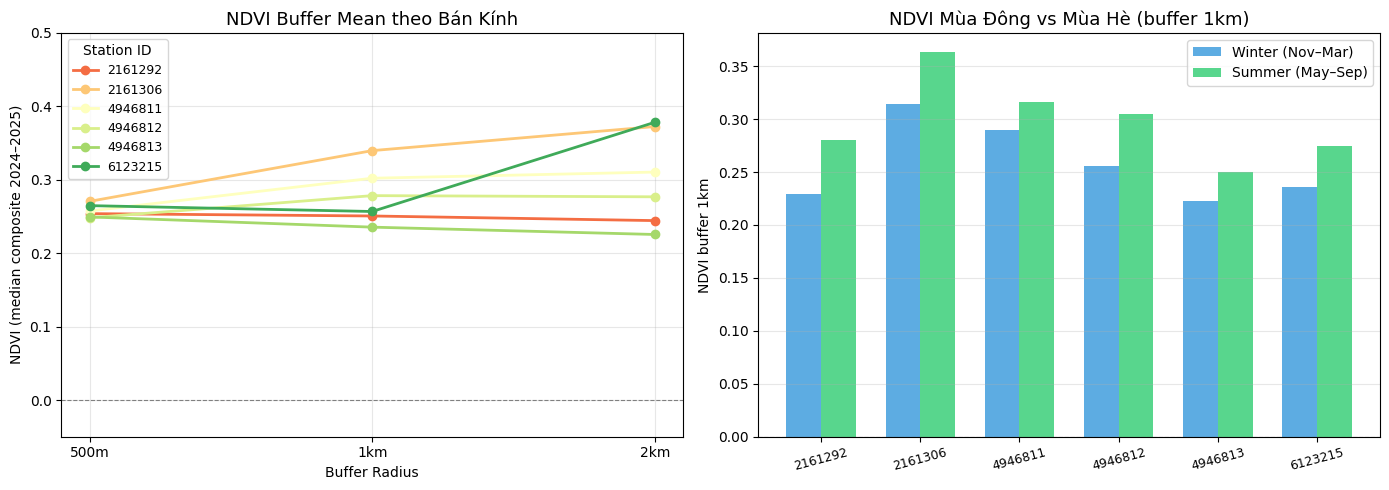

Saved: D:\Bussiness_plan\Multimodal_PM25\outputs\ndvi_buffer_stations.png


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sids   = [str(s) for s in df_ndvi['location_id']]
colors = plt.cm.RdYlGn([0.2, 0.35, 0.5, 0.6, 0.7, 0.85])  # đỏ = thấp, xanh = cao

# Plot 1: NDVI buffer mean theo buffer size
buf_cols_mean = ['ndvi_buffer_500m', 'ndvi_buffer_1km', 'ndvi_buffer_2km']
buf_labels    = ['500m', '1km', '2km']
for i, (sid_str, c) in enumerate(zip(sids, colors)):
    vals = [df_ndvi.loc[i, col] for col in buf_cols_mean]
    axes[0].plot(buf_labels, vals, marker='o', label=sid_str, color=c, linewidth=2)

axes[0].set_title('NDVI Buffer Mean theo Bán Kính', fontsize=13)
axes[0].set_ylabel('NDVI (median composite 2024–2025)')
axes[0].set_xlabel('Buffer Radius')
axes[0].legend(fontsize=9, title='Station ID')
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_ylim(-0.05, 0.5)

# Plot 2: Winter vs Summer NDVI tại buffer 1km
x = range(len(sids))
w = 0.35
w_vals = df_ndvi['ndvi_buffer_1km_winter'].values
s_vals = df_ndvi['ndvi_buffer_1km_summer'].values

bars1 = axes[1].bar([xi - w/2 for xi in x], w_vals, width=w,
                    color='#3498db', alpha=0.8, label='Winter (Nov–Mar)')
bars2 = axes[1].bar([xi + w/2 for xi in x], s_vals, width=w,
                    color='#2ecc71', alpha=0.8, label='Summer (May–Sep)')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(sids, rotation=15, fontsize=9)
axes[1].set_ylabel('NDVI buffer 1km')
axes[1].set_title('NDVI Mùa Đông vs Mùa Hè (buffer 1km)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
out_fig = ROOT / 'outputs/ndvi_buffer_stations.png'
out_fig.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_fig, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')

## Cell 7 — Lưu vào station_spatial_features.csv

In [7]:
NDVI_COLS = [c for c in df_ndvi.columns if c != 'location_id']

if OUT_CSV.exists():
    df_sf = pd.read_csv(OUT_CSV)
    drop = [c for c in NDVI_COLS if c in df_sf.columns]
    if drop:
        df_sf.drop(columns=drop, inplace=True)
        print(f'Dropped old NDVI cols: {drop}')
    df_sf = df_sf.merge(df_ndvi, on='location_id', how='left')
else:
    df_sf = df_ndvi

df_sf.to_csv(OUT_CSV, index=False)
print(f'Saved: {OUT_CSV}  shape={df_sf.shape}')

# Preview
mean_cols = [c for c in df_sf.columns if 'ndvi_buffer' in c and 'std' not in c
             and 'p10' not in c and 'p90' not in c]
print(df_sf[['location_id'] + mean_cols].to_string(index=False))

Dropped old NDVI cols: ['ndvi_buffer_500m', 'ndvi_buffer_500m_std', 'ndvi_buffer_500m_p10', 'ndvi_buffer_500m_p90', 'ndvi_buffer_1km', 'ndvi_buffer_1km_std', 'ndvi_buffer_1km_p10', 'ndvi_buffer_1km_p90', 'ndvi_buffer_2km', 'ndvi_buffer_2km_std', 'ndvi_buffer_2km_p10', 'ndvi_buffer_2km_p90', 'ndvi_buffer_1km_winter', 'ndvi_buffer_1km_summer']
Saved: D:\Bussiness_plan\Multimodal_PM25\data\processed\station_spatial_features.csv  shape=(6, 60)
 location_id  ndvi_buffer_500m  ndvi_buffer_1km  ndvi_buffer_2km  ndvi_buffer_1km_winter  ndvi_buffer_1km_summer
     2161292            0.2538           0.2506           0.2443                  0.2297                  0.2801
     2161306            0.2705           0.3396           0.3724                  0.3147                  0.3633
     4946811            0.2574           0.3020           0.3104                  0.2896                  0.3164
     4946812            0.2482           0.2783           0.2767                  0.2557                

## Cell 8 — Merge vào daily_merged.csv

In [8]:
main = pd.read_csv(MERGED, parse_dates=['date'])
print(f'daily_merged trước: {main.shape}')

# Chọn cột dùng cho model
MODEL_NDVI_COLS = [
    'location_id',
    'ndvi_buffer_500m',
    'ndvi_buffer_1km',
    'ndvi_buffer_2km',
    'ndvi_buffer_1km_std',     # độ đồng nhất thảm thực vật
    'ndvi_buffer_1km_winter',  # NDVI mùa đông
    'ndvi_buffer_1km_summer',  # NDVI mùa hè
]
keep = [c for c in MODEL_NDVI_COLS if c in df_ndvi.columns]

drop_existing = [c for c in keep[1:] if c in main.columns]
if drop_existing:
    main.drop(columns=drop_existing, inplace=True)

main = main.merge(df_ndvi[keep], on='location_id', how='left')

for col in keep[1:]:
    pct = main[col].notna().mean() * 100
    print(f'  {col}: {pct:.0f}% filled')

main.to_csv(MERGED, index=False)
print(f'\nUpdated: {MERGED}  shape={main.shape}')

daily_merged trước: (2566, 110)
  ndvi_buffer_500m: 100% filled
  ndvi_buffer_1km: 100% filled
  ndvi_buffer_2km: 100% filled
  ndvi_buffer_1km_std: 100% filled
  ndvi_buffer_1km_winter: 100% filled
  ndvi_buffer_1km_summer: 100% filled



Updated: D:\Bussiness_plan\Multimodal_PM25\data\processed\daily_merged.csv  shape=(2566, 116)


## Cell 9 — Thêm vào train_3d_v2.py

```python
# Trong tab_cols, sau urban fraction, thêm:
+ ["ndvi_buffer_500m", "ndvi_buffer_1km", "ndvi_buffer_2km",
   "ndvi_buffer_1km_std",
   "ndvi_buffer_1km_winter", "ndvi_buffer_1km_summer"]
```

Xóa cache neural và retrain:
```python
import shutil
shutil.rmtree('outputs/final_3d_v2/cache', ignore_errors=True)
```

**Lý do NDVI buffer khác với `ndvi_mean` hiện có:**
| | `ndvi_mean` (hiện có) | `ndvi_buffer_*` (mới) |
|---|---|---|
| Loại | Time-varying (thay đổi theo ngày) | Static (cố định per station) |
| Phạm vi | Pixel tại vị trí trạm | Buffer 500m/1km/2km không gian |
| Nguồn | Sentinel-2 daily pipeline | GEE median composite 2 năm |
| Ý nghĩa | Điều kiện thực vật ngày hôm đó | Đặc trưng môi trường xung quanh trạm |
| Nhiễu | Cao (mây, shadow) | Thấp (median composite lọc mây) |